# Hospital Readmission Prediction: Feature Engineering

**Objective:** Prepare the dataset for machine learning by controlling bias, analysing feature-target relationships, and constructing three interpretable clinical dimensions.

**Input:** `diabetic_data_clean.csv` (output of `01_data_preparation.ipynb`)
**Stack:** Python, pandas, numpy, scikit-learn, matplotlib, seaborn

---

**Steps covered in this notebook:**
1. Data Preparation & Bias Control: class imbalance analysis and train/test split (performed before any feature engineering to avoid data leakage)
2. Correlation Analysis (training set only): identification of variables most associated with hospital readmission
3. Clinical Dimensionality Reduction: construction of three interpretable clinical features from the original variables


# Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

PLOT_DIR = "../Plot"
os.makedirs(PLOT_DIR, exist_ok=True)

df = pd.read_csv("../data/diabetic_data_clean.csv")

print(f"Dataset loaded: {df.shape[0]:,} patients, {df.shape[1]} variables")


Dataset loaded: 101,766 patients, 48 variables


C:\Users\Juliette Vanessa\AppData\Local\Temp\ipykernel_42732\4230624744.py:15: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/diabetic_data_clean.csv")


# 5. Data Preparation & Bias Control

## 5.1 Class Imbalance Check

**Question:** Is the target variable balanced, and what are the implications for modelling?

**Context & Clinical Relevance:** Class imbalance is a common challenge in clinical prediction tasks: the event of interest (readmission) is typically less frequent than the non-event. A model trained on imbalanced data without correction tends to be biased toward the majority class, meaning it would systematically under-detect readmitted patients, the worst possible error in a clinical screening tool.

**Approach:** The class distribution is checked and the imbalance ratio quantified, which directly justifies the use of `class_weight='balanced'` in the Random Forest classifier in Phase 8.



CLASS DISTRIBUTION
is_readmitted
0    53.91
1    46.09
Name: proportion, dtype: float64


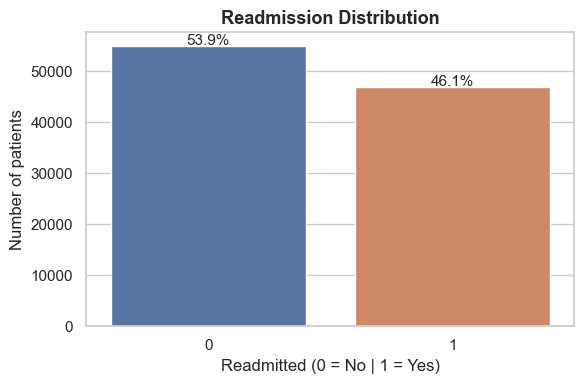


Readmitted patients represented 46.1% of the cohort.
Imbalance ratio: 1.17:1
This imbalance justifies the use of class_weight='balanced' and recall-focused evaluation metrics.


In [2]:
print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)

class_dist = df['is_readmitted'].value_counts(normalize=True) * 100
print(class_dist.round(2))

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    x='is_readmitted',
    data=df,
    hue='is_readmitted',
    palette=['#4C72B0', '#DD8452'],
    legend=False,
    ax=ax
)

ax.set_title("Readmission Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Readmitted (0 = No | 1 = Yes)")
ax.set_ylabel("Number of patients")

for i, bar in enumerate(ax.patches):
    val = class_dist.iloc[i]
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f"{val:.1f}%",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.savefig(
    os.path.join(PLOT_DIR, "class_distribution.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

readmitted_pct = class_dist.get(1, 0)

imbalance_ratio = (
    class_dist.max() / class_dist.min()
    if class_dist.min() > 0
    else np.nan
)

print(f"\nReadmitted patients represented {readmitted_pct:.1f}% of the cohort.")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

print(
    "This imbalance justifies the use of class_weight='balanced' "
    "and recall-focused evaluation metrics."
)

## 5.2 Train / Test Split

**Question:** When should the train/test split happen relative to feature engineering?

**Context & Clinical Relevance:** Data leakage is a major source of bias in predictive modelling. It occurs when information from the test set influences model development, leading to overly optimistic performance estimates. In a clinical setting, this could make a model appear more accurate during development than it would be once deployed on unseen patients. If steps such as correlation analysis, feature weighting, scaling, or variable selection are performed before the train/test split, information from the future evaluation set can inadvertently influence training.

**Approach:** All subsequent preprocessing steps (correlation calculations, feature weighting, scaling parameter estimation, composite score construction) are derived solely from the training data (`X_train_raw`, `y_train`). The same transformations are then applied to the test set using parameters learned from training only.

> The train/test split is intentionally performed before any feature engineering, so that no information from the held-out test set contributes to feature construction.


In [3]:
FEATURES_RAW = [
    'number_diagnoses',
    'number_inpatient', 'number_emergency', 'number_outpatient',
    'time_in_hospital', 'num_lab_procedures', 'num_medications'
]

df['is_readmitted'] = (df['readmitted'] != 'NO').astype(int)

X_raw = df[FEATURES_RAW]
y     = df['is_readmitted']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)
print("\nClass distribution after split:")
print(f"Training set : {X_train_raw.shape[0]:,} patients")
print(f"Test set     : {X_test_raw.shape[0]:,} patients (held-out — never touched until final evaluation)")


Class distribution after split:
Training set : 81,412 patients
Test set     : 20,354 patients (held-out — never touched until final evaluation)


# 6. Correlation Analysis (Training Set Only)

**Question:** Which clinical variables show the strongest association with hospital readmission?

**Context & Clinical Relevance:** Before constructing composite clinical dimensions, it's useful to quantify the relationship between each candidate predictor and the readmission outcome. This identifies which variables carry the strongest signal and informs the dimensionality reduction strategy. Variables reflecting prior healthcare utilisation (inpatient, emergency, outpatient visits) are expected to capture underlying disease instability and may be strongly associated with future readmission risk.

**Approach:** Correlations are computed on the training set only (`X_train_raw` combined with `y_train`) to prevent information leakage from the held-out test set. Because the outcome variable is binary (`is_readmitted`), Pearson correlation is mathematically equivalent to the point-biserial correlation coefficient here, and gives a simple measure of linear association between each predictor and readmission status.

The resulting coefficients serve two purposes:
1. **Clinical interpretation:** identify variables most strongly associated with readmission.
2. **Feature engineering:** provide relative weights for the composite clinical dimensions.

These coefficients are used as measures of association rather than causal importance, to guide feature construction based on patterns observed in the training data.


=== Correlations with readmission (training set only) ===


,Correlation
number_inpatient,0.216551
number_diagnoses,0.112782
number_emergency,0.102565
number_outpatient,0.083240
time_in_hospital,0.050696
num_medications,0.044526
num_lab_procedures,0.038636


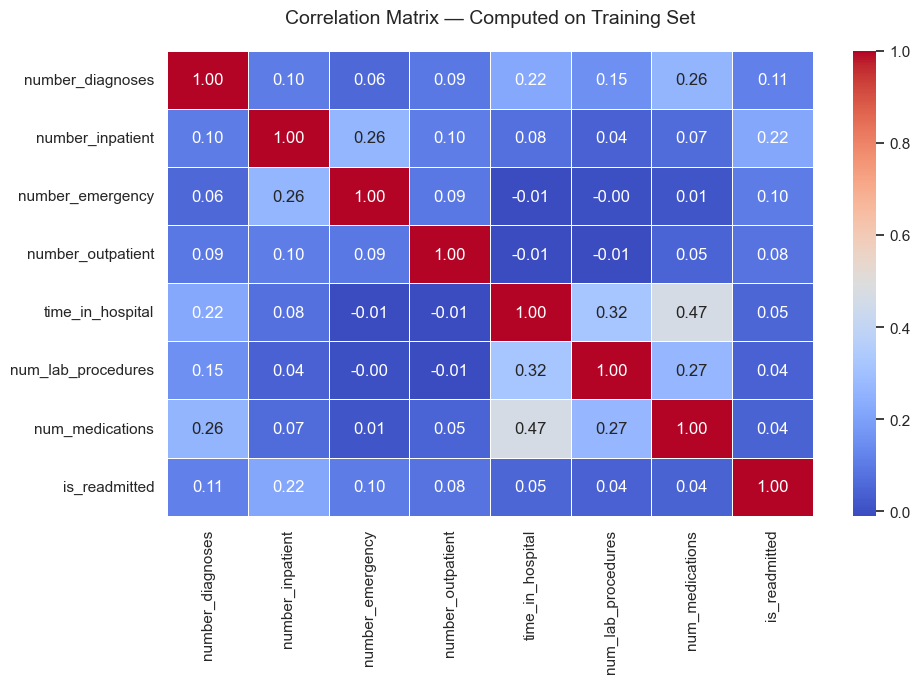

In [4]:
print("=== Correlations with readmission (training set only) ===")

train_df = X_train_raw.copy()
train_df['is_readmitted'] = y_train.values

correlations = (
    train_df
    .corr(numeric_only=True)["is_readmitted"]
    .sort_values(ascending=False)
)

corr_target = (
    correlations
    .drop("is_readmitted")
    .rename("Correlation")
    .to_frame()
)

display(corr_target)

fig, ax = plt.subplots(figsize=(10, 7))
cols_heatmap = FEATURES_RAW + ['is_readmitted']
sns.heatmap(train_df[cols_heatmap].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Computed on Training Set',
             fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOT_DIR, "correlation_matrix.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# 7. Clinical Dimensionality Reduction

## 7.1 Rationale

**Question:** How do we reduce 7 variables into 3 interpretable clinical dimensions without losing medical meaning?

**Context & Clinical Relevance:** Principal Component Analysis (PCA) is a widely used dimensionality reduction technique that optimises variance capture, but it produces linear combinations of variables that aren't clinically interpretable, limiting their usefulness in healthcare decision-making. Clinical applications instead call for interpretable constructs that healthcare professionals can understand and act on. Dimensions such as Pathological Terrain, Chronic Instability, and Episode Severity map directly onto established medical reasoning; the Pathological Terrain dimension is conceptually aligned with established clinical risk frameworks such as the Charlson Comorbidity Index.

**Approach:** An expert-driven dimensionality reduction is used, prioritising interpretability over variance optimisation, guided by:
- Pearson correlations with the target (training set only)
- Clinical semantics grounded in established medical concepts
- Structured grouping of variables into interpretable clinical constructs

## 7.2 Definition of Clinical Dimensions

**1. Pathological Terrain** (underlying chronic disease complexity)
Variable: `number_diagnoses`
A higher number of diagnoses reflects greater clinical complexity and multimorbidity.

**2. Chronic Instability** (healthcare utilisation history)
Variables: `number_inpatient`, `number_emergency`, `number_outpatient`
These reflect prior acute episodes and frequent healthcare utilisation, both strongly associated with future readmission risk.

**3. Episode Severity** (acute care intensity)
Variables: `time_in_hospital`, `num_lab_procedures`, `num_medications`
Longer stays and higher diagnostic activity indicate more severe acute clinical presentations. `num_medications` correlates with both Pathological Terrain and Episode Severity; based on the correlation matrix, it's assigned to Episode Severity, since it shows a stronger empirical association with `time_in_hospital`.

| Dimension | Variables | Clinical Concept |
|---|---|---|
| **Pathological Terrain** | `number_diagnoses` | Comorbidity burden (cf. Charlson score) |
| **Chronic Instability** | `number_inpatient`, `number_emergency`, `number_outpatient` | Past healthcare utilisation |
| **Episode Severity** | `time_in_hospital`, `num_lab_procedures`, `num_medications` | Current episode intensity |


## 7.3 Weighting Strategy

Each dimension is built in two steps:
1. **MinMaxScaler** fitted on training data only, scaling variables to [0, 1]
2. **Correlation weighting**: each variable is weighted by its Pearson r with `is_readmitted`, computed on the training set

This ensures stronger predictors contribute proportionally more to each composite score while preventing data leakage.

> Correlation weights are used strictly as a heuristic signal strength to align dimensions clinically, rather than as inferential statistical estimates.


In [5]:
cols_instab = ['number_inpatient', 'number_emergency', 'number_outpatient']
cols_sev = ['time_in_hospital', 'num_lab_procedures', 'num_medications']

# --- correlation-based weights (training set only) ---
w_instab = np.array([
    train_df[c].corr(train_df['is_readmitted']) for c in cols_instab
])
w_instab = w_instab / w_instab.sum()

w_sev = np.array([
    train_df[c].corr(train_df['is_readmitted']) for c in cols_sev
])
w_sev = w_sev / w_sev.sum()

print("=== Normalized weights (training set only) ===")
print("Dim instability:", dict(zip(cols_instab, w_instab)))
print("Dim severity:", dict(zip(cols_sev, w_sev)))

# --- scaler fitted on training data only ---
scaler = MinMaxScaler()
scaler.fit(X_train_raw[cols_instab + cols_sev + ['number_diagnoses']])

def build_dims(X_df):

    X_scaled = pd.DataFrame(
        scaler.transform(
            X_df[cols_instab + cols_sev + ['number_diagnoses']]
        ),
        columns=cols_instab + cols_sev + ['number_diagnoses'],
        index=X_df.index
    )

    dim_terrain = X_scaled['number_diagnoses']

    dim_instability = sum(
        X_scaled[c] * w for c, w in zip(cols_instab, w_instab)
    )

    dim_severity = sum(
        X_scaled[c] * w for c, w in zip(cols_sev, w_sev)
    )

    return pd.DataFrame({
        'dim_terrain': dim_terrain,
        'dim_instability': dim_instability,
        'dim_severity': dim_severity
    }, index=X_df.index)

# Build features
X_train = build_dims(X_train_raw)
X_test = build_dims(X_test_raw)

import pandas as pd

instab_df = pd.DataFrame({
    "Feature": cols_instab,
    "Weight (%)": (w_instab * 100).round(1)
}).sort_values("Weight (%)", ascending=False)

sev_df = pd.DataFrame({
    "Feature": cols_sev,
    "Weight (%)": (w_sev * 100).round(1)
}).sort_values("Weight (%)", ascending=False)

print("\n=== Dimensional Weights ===")
print("\nChronic Instability")
display(instab_df)

print("\nEpisode Severity")
display(sev_df)

=== Normalized weights (training set only) ===
Dim instability: {'number_inpatient': np.float64(0.5382059592023617), 'number_emergency': np.float64(0.2549116851360546), 'number_outpatient': np.float64(0.20688235566158367)}
Dim severity: {'time_in_hospital': np.float64(0.37872728665937067), 'num_lab_procedures': np.float64(0.2886331078504311), 'num_medications': np.float64(0.3326396054901981)}

=== Dimensional Weights ===

Chronic Instability


,Feature,Weight (%)
0,number_inpatient,53.8
1,number_emergency,25.5
2,number_outpatient,20.7



Episode Severity


,Feature,Weight (%)
0,time_in_hospital,37.9
2,num_medications,33.3
1,num_lab_procedures,28.9


## 7.4 Quick Check

In [6]:
print("=== Predictive power of the 3 clinical axes (training set) ===")
check = X_train.copy()
check['is_readmitted'] = y_train.values

print("Correlation with readmission:")
for col in X_train.columns:
    print(f"{col}: {check[col].corr(check['is_readmitted']):.3f}")

=== Predictive power of the 3 clinical axes (training set) ===
Correlation with readmission:
dim_terrain: 0.113
dim_instability: 0.227
dim_severity: 0.059


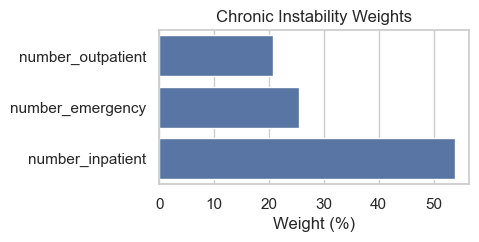

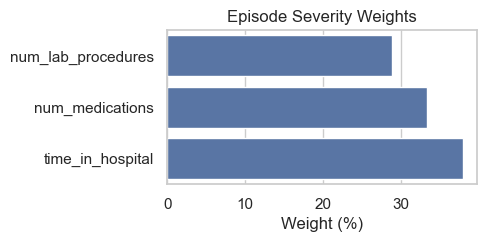

In [7]:
def plot_weights(features, weights, title):
    df_plot = pd.DataFrame({
        "Feature": features,
        "Weight": weights * 100
    }).sort_values("Weight", ascending=True)

    plt.figure(figsize=(4,2))
    sns.barplot(data=df_plot, x="Weight", y="Feature")
    plt.title(title)
    plt.xlabel("Weight (%)")
    plt.ylabel("")
    plt.show()

plot_weights(cols_instab, w_instab, "Chronic Instability Weights")
plot_weights(cols_sev, w_sev, "Episode Severity Weights")

# Export Feature Matrix

In [8]:
import joblib
import os

# --- Export feature matrices ---
X_train_export = X_train.copy()
X_train_export['is_readmitted'] = y_train.values
X_train_export['split'] = 'train'

X_test_export = X_test.copy()
X_test_export['is_readmitted'] = y_test.values
X_test_export['split'] = 'test'

features_full = pd.concat([X_train_export, X_test_export])

features_full.to_csv(
    r"..\data\features.csv",
    index=False
)

# --- Save preprocessing objects for reproducibility ---
feature_params = {
    'scaler': scaler,
    'w_instab': w_instab,
    'w_sev': w_sev,
    'cols_instab': cols_instab,
    'cols_sev': cols_sev
}

joblib.dump(
    feature_params,
    r"..\models\feature_params.pkl"
)


# --- Logging ---
print(f"Feature matrix saved:")
print(f"  Train: {len(X_train_export):,}")
print(f"  Test : {len(X_test_export):,}")
print(f"Total : {len(features_full):,}")

print("\nFeature parameters saved → models/feature_params.pkl")
print("\nFeature list:")
print(features_full.columns.tolist())

Feature matrix saved:
  Train: 81,412
  Test : 20,354
Total : 101,766

Feature parameters saved → models/feature_params.pkl

Feature list:
['dim_terrain', 'dim_instability', 'dim_severity', 'is_readmitted', 'split']


## Feature Engineering Summary

- Train set: 81,412 rows
- Test set: 20,354 rows
- Total dataset exported: 101,766 rows
- Feature matrix: 5 columns
- Target distribution (train): 54.2% not readmitted, 45.8% readmitted

Files created:
- `data/features.csv`
- `models/feature_params.pkl`

**Next step:** `03_modelling.ipynb`, model training and evaluation.
